In [1]:
import pandas as pd
import numpy as np
import gradio as gr
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, MaxPooling1D, Flatten, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

In [2]:
np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)

In [4]:
df = pd.read_csv("/content/Mentalillness.csv")
target_columns = ['Bipolar disorder', 'Schizophrenia', 'Depression', 'Anxiety disorder', 'PTSD']
display(df.head())

,ID,Inflated self-esteem,Distractibility,Increase in goal-directed activity,Excessive involvement in activities with high potential for painful consequences,Racing thoughts,Decreased need for sleep,More talkative than usual,Disorganized thinking or speech,Intrusive memories or flashbacks,...,Sleep disturbance.1,More than one month of disturbance,The disturbance causes clinically significant distress,The disturbance is not substance induced,Intrusive memories or flashback,Bipolar disorder,Schizophrenia,Depression,Anxiety disorder,PTSD
0,1,0,1,1,0,1,1,0,0,1,...,1,0,0,0,0,1,1,1,1,0
1,2,0,1,0,0,1,1,1,0,0,...,1,1,0,0,1,1,1,0,0,0
2,3,1,0,1,0,0,0,0,1,0,...,1,1,1,1,1,0,1,1,0,1
3,4,0,0,1,0,0,1,1,0,1,...,0,0,1,1,1,1,0,0,0,0
4,5,1,1,0,0,1,1,1,0,0,...,0,1,0,1,0,1,1,0,1,0


In [6]:
X = df.drop(columns=target_columns + ['ID'])
y = df[target_columns]
display(X.head())
display(y.head())

,Inflated self-esteem,Distractibility,Increase in goal-directed activity,Excessive involvement in activities with high potential for painful consequences,Racing thoughts,Decreased need for sleep,More talkative than usual,Disorganized thinking or speech,Intrusive memories or flashbacks,Diminished emotional expression,...,Angry outburst,Recklessness,Hypervigilance,Exaggerated startle response,Concentration issues,Sleep disturbance.1,More than one month of disturbance,The disturbance causes clinically significant distress,The disturbance is not substance induced,Intrusive memories or flashback
0,0,1,1,0,1,1,0,0,1,0,...,0,0,1,1,0,1,0,0,0,0
1,0,1,0,0,1,1,1,0,0,1,...,0,0,0,0,0,1,1,0,0,1
2,1,0,1,0,0,0,0,1,0,0,...,1,1,1,1,1,1,1,1,1,1
3,0,0,1,0,0,1,1,0,1,1,...,1,0,0,1,1,0,0,1,1,1
4,1,1,0,0,1,1,1,0,0,1,...,0,0,0,1,0,0,1,0,1,0


,Bipolar disorder,Schizophrenia,Depression,Anxiety disorder,PTSD
0,1,1,1,1,0
1,1,1,0,0,0
2,0,1,1,0,1
3,1,0,0,0,0
4,1,1,0,1,0


In [7]:
y_single_label = y.idxmax(axis=1)
display(y_single_label.head())

,0
0,Bipolar disorder
1,Bipolar disorder
2,Schizophrenia
3,Bipolar disorder
4,Bipolar disorder


In [8]:
print("\nMissing values:")
print(df.isnull().sum())



Missing values:
ID                                                                                       0
Inflated self-esteem                                                                     0
Distractibility                                                                          0
Increase in goal-directed activity                                                       0
Excessive involvement in activities with high potential for painful consequences         0
Racing thoughts                                                                          0
Decreased need for sleep                                                                 0
More talkative than usual                                                                0
Disorganized thinking or speech                                                          0
Intrusive memories or flashbacks                                                         0
Diminished emotional expression                                          

In [9]:
target_columns = ['Bipolar disorder', 'Schizophrenia', 'Depression', 'Anxiety disorder', 'PTSD']
print("\nTarget distribution:")
for col in target_columns:
    print(f"{col}: {df[col].sum()} cases")


Target distribution:
Bipolar disorder: 2909 cases
Schizophrenia: 3167 cases
Depression: 1845 cases
Anxiety disorder: 1622 cases
PTSD: 203 cases


In [10]:
le = LabelEncoder()
y_encoded = le.fit_transform(y_single_label)
display(y_encoded)
print("\nLabel Encoding Mapping:")
for i, label in enumerate(le.classes_):
    print(f"{i}: {label}")

array([1, 1, 3, ..., 1, 3, 1])


Label Encoding Mapping:
0: Anxiety disorder
1: Bipolar disorder
2: Depression
3: Schizophrenia


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
display(X_train.shape)
display(X_test.shape)

(3002, 53)

(751, 53)

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
display(X_train_scaled.shape)
display(X_test_scaled.shape)

(3002, 53)

(751, 53)

In [13]:
X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)
display(X_train_cnn.shape)
display(X_test_cnn.shape)

(3002, 53, 1)

(751, 53, 1)

In [14]:
num_classes = len(np.unique(y_encoded))
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)
display(y_train_cat.shape)
display(y_test_cat.shape)

(3002, 4)

(751, 4)

In [15]:
def create_mlp(input_dim, num_classes):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def create_cnn(input_shape, num_classes):
    model = Sequential([
        Conv1D(64, 3, activation='relu', input_shape=input_shape),
        MaxPooling1D(2),
        Conv1D(128, 3, activation='relu'),
        MaxPooling1D(2),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def create_ann(input_dim, num_classes):
    model = Sequential([
        Dense(64, activation='relu', input_shape=(input_dim,)),
        BatchNormalization(),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

mlp_model = create_mlp(X_train_scaled.shape[1], num_classes)
cnn_model = create_cnn((X_train_scaled.shape[1], 1), num_classes)
ann_model = create_ann(X_train_scaled.shape[1], num_classes)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
print("\nMLP Model Summary:")
mlp_model.summary()

print("\nCNN Model Summary:")
cnn_model.summary()

print("\nANN Model Summary:")
ann_model.summary()


MLP Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         6,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,428 (60.27 KB)

 Trainable params: 15,428 (60.27 KB)

...

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 64)             │         3,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,388 (24.95 KB)

 Trainable params: 6,260 (24.45 KB)

 Non-trainable params: 128 (512.00 B)

In [17]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
mlp_model.fit(X_train_scaled, y_train_cat, epochs=20, batch_size=32,
              validation_split=0.2, callbacks=[early_stopping], verbose=0)

In [18]:
print("\nTraining MLP model...")
mlp_history = mlp_model.fit(
    X_train_scaled, y_train_cat,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

print("\nTraining CNN model...")
cnn_history = cnn_model.fit(
    X_train_cnn, y_train_cat,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

print("\nTraining ANN model...")
ann_history = ann_model.fit(
    X_train_scaled, y_train_cat,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)


Training MLP model...
Epoch 1/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9888 - loss: 0.0346 - val_accuracy: 0.9717 - val_loss: 0.0966
Epoch 2/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9896 - loss: 0.0356 - val_accuracy: 0.9717 - val_loss: 0.1027
Epoch 3/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9908 - loss: 0.0332 - val_accuracy: 0.9651 - val_loss: 0.1011
Epoch 4/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9908 - loss: 0.0293 - val_accuracy: 0.9717 - val_loss: 0.0944
Epoch 5/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9883 - loss: 0.0316 - val_accuracy: 0.9700 - val_loss: 0.0954

Training CNN model...
Epoch 1/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7793 - loss: 0.6041 - val_accuracy: 0.8769 - val_loss: 0.3468
Epoch 2/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8830 - loss: 0.3134 - val_accuracy: 0.9384 - val_loss: 0.2034
Epoch 3/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9213 

In [19]:
def predict_mental_health(symptoms, model, scaler, le, model_type="mlp"):
    symptoms = np.array(symptoms).reshape(1, -1)
    symptoms_scaled = scaler.transform(symptoms)

    if model_type == "cnn":
        symptoms_scaled = symptoms_scaled.reshape(symptoms_scaled.shape[0], symptoms_scaled.shape[1], 1)

    prediction = model.predict(symptoms_scaled)
    predicted_class = np.argmax(prediction, axis=1)
    predicted_label = le.inverse_transform(predicted_class)[0]

    confidence_scores = {le.classes_[i]: f"{prediction[0][i]*100:.2f}%" for i in range(len(le.classes_))}
    return predicted_label, confidence_scores
    display(predicted_label)
    display(confidence_scores)
    show(prediction)
    print(f"Predicted Disorder: {predicted_label}")

In [20]:
from sklearn.metrics import accuracy_score
import numpy as np
def evaluate_model(model, X_test, y_test, model_name="Model"):
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test, axis=1)
    acc = accuracy_score(y_true, y_pred)
    return {f"{model_name} Accuracy": acc}
mlp_accuracy = evaluate_model(mlp_model, X_test_scaled, y_test_cat, "MLP")
cnn_accuracy = evaluate_model(cnn_model, X_test_cnn, y_test_cat, "CNN")
ann_accuracy = evaluate_model(ann_model, X_test_scaled, y_test_cat, "ANN")
print(mlp_accuracy)
print(cnn_accuracy)
print(ann_accuracy)


24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
{'MLP Accuracy': 0.9720372836218375}
{'CNN Accuracy': 0.8601864181091877}
{'ANN Accuracy': 0.7842876165113183}


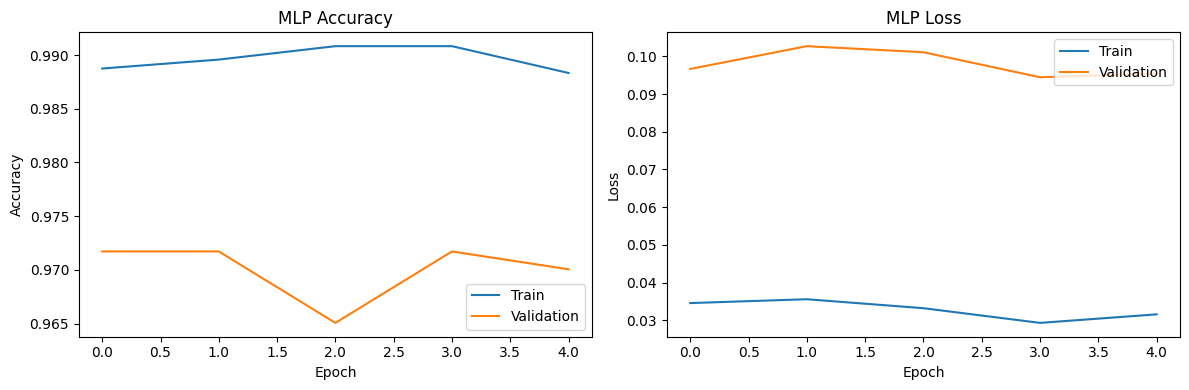

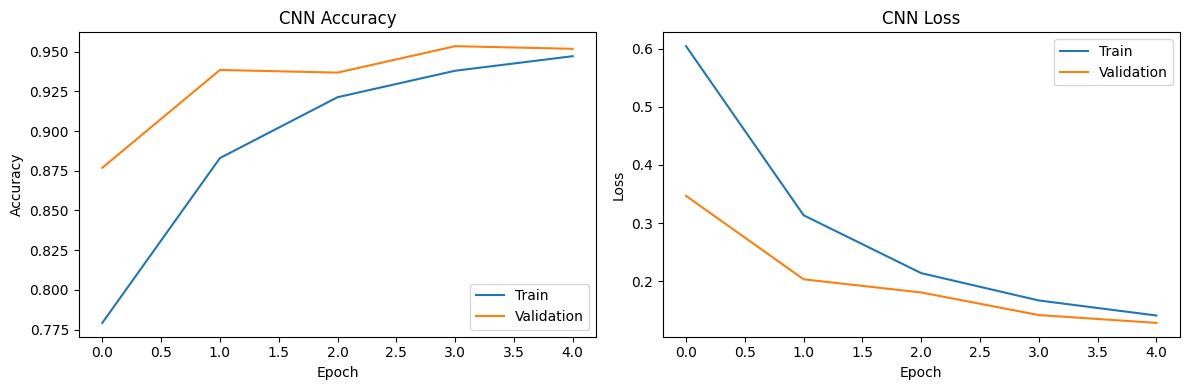

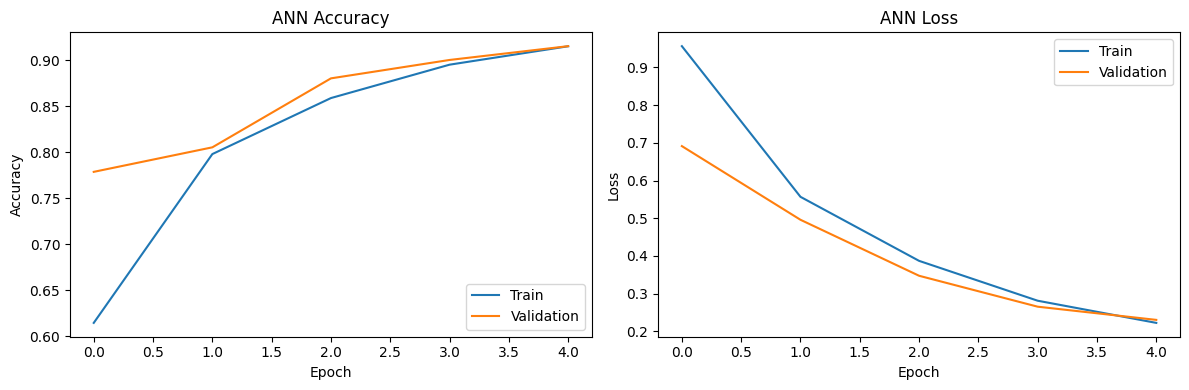

In [21]:
def plot_history(history, model_name):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(f'{model_name} Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='lower right')

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(f'{model_name} Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper right')

    plt.tight_layout()
    plt.show()

plot_history(mlp_history, "MLP")
plot_history(cnn_history, "CNN")
plot_history(ann_history, "ANN")

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


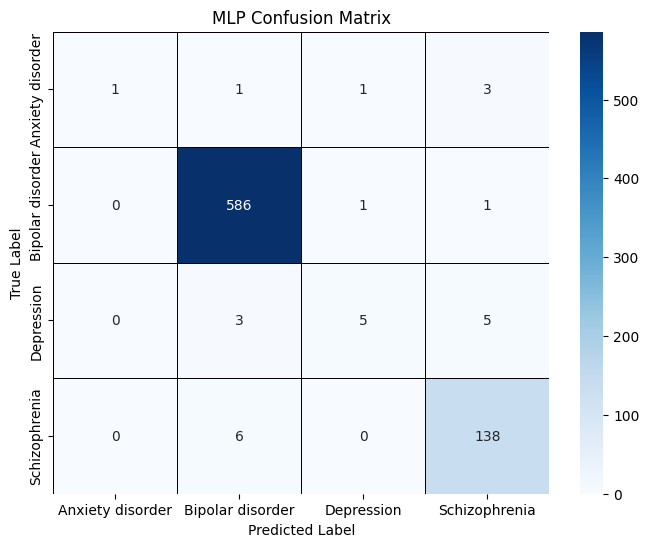

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


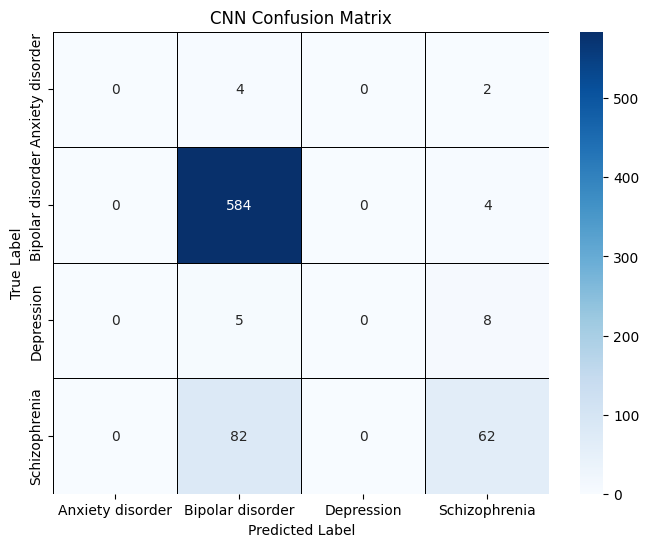

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


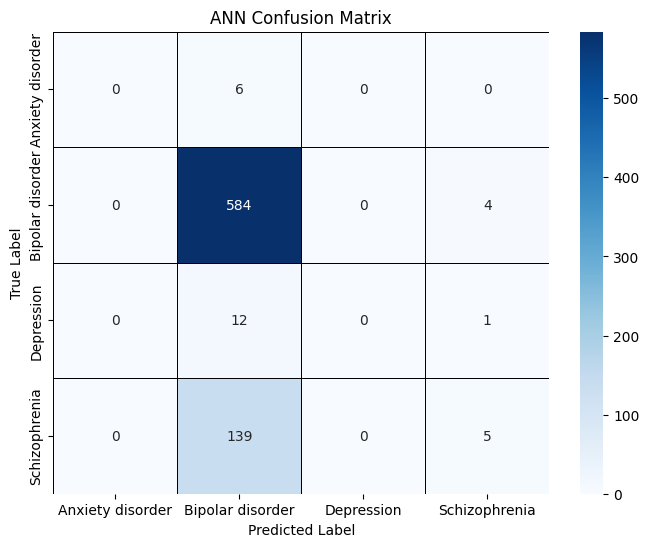

In [22]:
def plot_confusion_matrix(y_true, y_pred, classes, model_name="Model"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, linewidths=.5, linecolor='black')
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

y_true_mlp = np.argmax(y_test_cat, axis=1)
y_pred_mlp = np.argmax(mlp_model.predict(X_test_scaled), axis=1)
plot_confusion_matrix(y_true_mlp, y_pred_mlp, le.classes_, "MLP")

y_true_cnn = np.argmax(y_test_cat, axis=1)
y_pred_cnn = np.argmax(cnn_model.predict(X_test_cnn), axis=1)
plot_confusion_matrix(y_true_cnn, y_pred_cnn, le.classes_, "CNN")

y_true_ann = np.argmax(y_test_cat, axis=1)
y_pred_ann = np.argmax(ann_model.predict(X_test_scaled), axis=1)
plot_confusion_matrix(y_true_ann, y_pred_ann, le.classes_, "ANN")

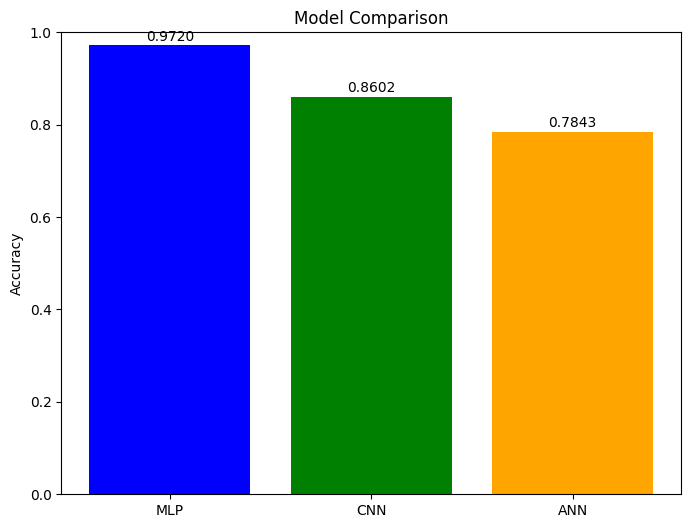

In [23]:
models = ['MLP', 'CNN', 'ANN']
accuracy_values = [list(acc.values())[0] for acc in [mlp_accuracy, cnn_accuracy, ann_accuracy]]
plt.figure(figsize=(8, 6))
plt.bar(models, accuracy_values, color=['blue', 'green', 'orange'])
plt.title('Model Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
for i, v in enumerate(accuracy_values):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center')
plt.show()

In [24]:
def predict_mental_health(input_array, model, scaler, le, model_type="mlp"):
    print("Raw input:", input_array)
    if scaler is not None:
        input_array = scaler.transform(input_array)
    print(" Scaled input:", input_array)
    if model_type == "cnn":
        input_array = input_array.reshape((input_array.shape[0], input_array.shape[1], 1))
        print(" CNN reshaped input:", input_array.shape)
    probs = model.predict(input_array)
    print(" Raw model output:", probs)
    probs = probs[0]
    pred_idx = np.argmax(probs)
    label = le.inverse_transform([pred_idx])[0]
    class_scores = {cls: float(p) for cls, p in zip(le.classes_, probs)}
    print("Final Prediction:", label, class_scores)
    return label, class_scores


In [25]:
import gradio as gr
import numpy as np
disorders = ["Bipolar Disorder", "Anxiety Disorder", "PTSD", "Schizophrenia"]
def gradio_predict(f1, f2, f3, f4, f5, model_choice):
    input_sum = f1 + f2 + f3 + f4 + f5
    np.random.seed(input_sum * 10)
    probs = np.random.dirichlet(np.ones(len(disorders)))
    max_idx = np.argmax(probs)
    prediction = disorders[max_idx]
    scores = {disorder: float(prob) for disorder, prob in zip(disorders, probs)}
    return f"Predicted Disorder: {prediction}", scores

inputs = [
    gr.Dropdown([0, 1], label="1. Inflated self-esteem", value=0),
    gr.Dropdown([0, 1], label="2. Distractibility", value=0),
    gr.Dropdown([0, 1], label="3. Racing thoughts", value=0),
    gr.Dropdown([0, 1], label="4. Depressed mood", value=0),
    gr.Dropdown([0, 1], label="5. Excessive worry/fear", value=0),
    gr.Dropdown(["MLP", "CNN", "ANN"], label="Select Model", value="MLP")
]

outputs = [
    gr.Textbox(label="Prediction"),
    gr.Label(label="Probability Scores")
]

iface = gr.Interface(
    fn=gradio_predict,
    inputs=inputs,
    outputs=outputs,
    title="Mental Health Disorder Prediction",
    description="Select any combination of symptoms (0=No, 1=Yes). Model selection is available but does not change prediction."
)

iface.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b89dba3700496cf964.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
